In [2]:
import pypowsybl as pp
import pypowsybl.loadflow as lf



network = pp.network.load('Svedala_CGMES3.0_CIM17.zip', post_processors=['replaceTieLinesByLines'])
lf.run_ac(network)



[ComponentResult(connected_component_num=0, synchronous_component_num=0, status=CONVERGED, status_text=Converged, iteration_count=10, reference_bus_id='eaa25262-839d-4abf-ad2c-62e2e252bfee_0', slack_bus_results=[SlackBusResult(id='eaa25262-839d-4abf-ad2c-62e2e252bfee_0', active_power_mismatch=0.16358454744439532)], distributed_active_power=-67.01725998312578)]

In [3]:
buses = network.get_buses()
print(buses.loc['eaa25262-839d-4abf-ad2c-62e2e252bfee_0'])

name                                          NORRÅS_4_FT42_0
v_mag                                              391.330339
v_angle                                                   0.0
connected_component                                         0
synchronous_component                                       0
voltage_level_id         eaa25262-839d-4abf-ad2c-62e2e252bfee
Name: eaa25262-839d-4abf-ad2c-62e2e252bfee_0, dtype: object


Result

In [4]:
buses = network.get_buses()
print(buses['v_mag'].round(2))
buses.nlargest(10, 'v_mag')
print(buses.loc['1eed5c53-4894-4ace-b0ad-fe0bea6eeccd_0'])

id
fcad8062-867d-4020-8b9c-de5924e80357_0    144.63
1eed5c53-4894-4ace-b0ad-fe0bea6eeccd_0    407.59
f825d10b-a202-44e8-85d1-e4f78dc3dcf7_0     17.50
f825d10b-a202-44e8-85d1-e4f78dc3dcf7_1     17.50
fd4e8daa-7b82-49ad-9e7f-b3da8b0e9d58_1     10.08
                                           ...  
7b29b41f-a3e7-426c-aa38-06e9253b50ff_0     48.43
04bc67f0-fc8e-4c6a-a63a-56ccc4595875_0     16.62
b8e4bf45-72bb-42aa-9b61-22fb69ce014a_0    123.84
1303c35a-11c7-43cb-8906-24654c204ab9_0     48.34
4a237813-ed80-44d8-a1eb-d0c08765a486_0     10.43
Name: v_mag, Length: 104, dtype: float64
name                                           AGGAN_4_CT11_0
v_mag                                              407.594305
v_angle                                             51.282546
connected_component                                         0
synchronous_component                                       0
voltage_level_id         1eed5c53-4894-4ace-b0ad-fe0bea6eeccd
Name: 1eed5c53-4894-4ace-b0ad-fe0bea6eeccd_0,

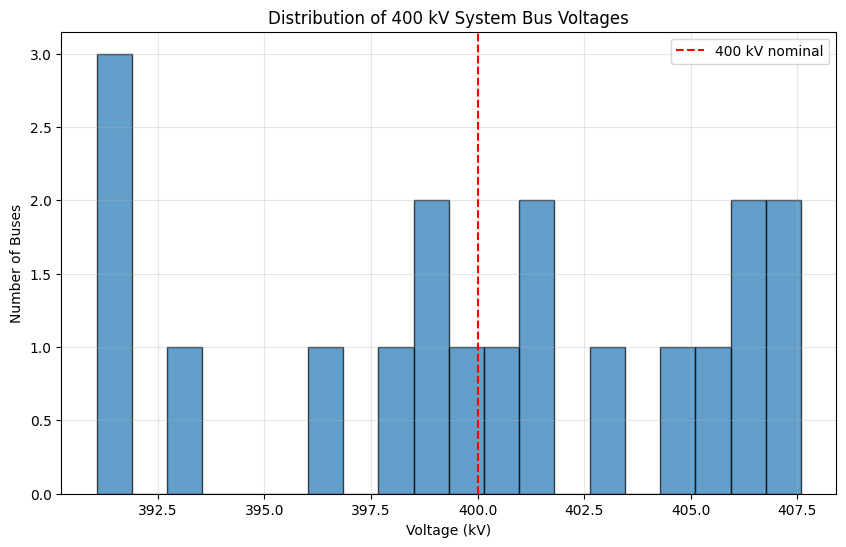

In [5]:
import matplotlib.pyplot as plt

# Filter 400 kV range buses
buses_400kv = buses[(buses['v_mag'] >= 380) & (buses['v_mag'] <= 420)]

if not buses_400kv.empty:
    plt.figure(figsize=(10, 6))
    plt.hist(buses_400kv['v_mag'], bins=20, edgecolor='black', alpha=0.7)
    plt.axvline(400, color='red', linestyle='--', label='400 kV nominal')
    plt.xlabel('Voltage (kV)')
    plt.ylabel('Number of Buses')
    plt.title('Distribution of 400 kV System Bus Voltages')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [7]:
print(buses.columns)


Index(['name', 'v_mag', 'v_angle', 'connected_component',
       'synchronous_component', 'voltage_level_id'],
      dtype='object')


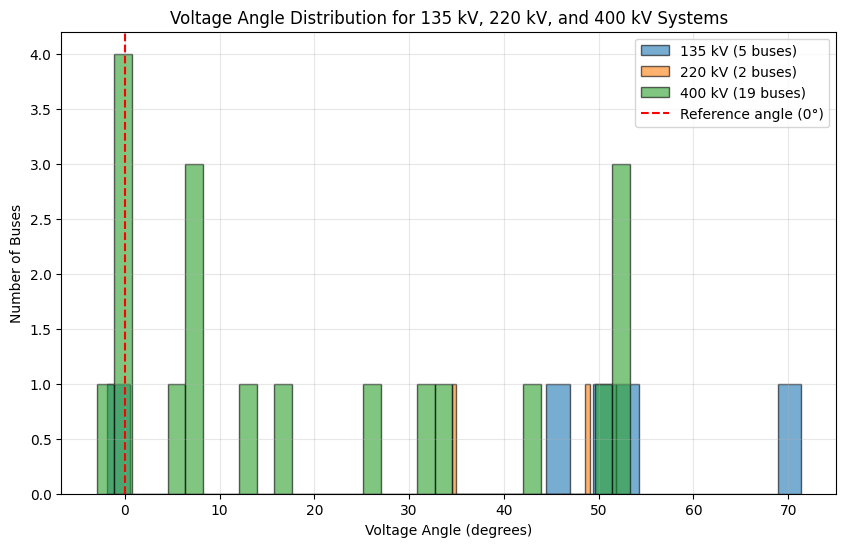

In [8]:
import matplotlib.pyplot as plt

# Define voltage level ranges (you can tweak ± ranges as needed)
voltage_levels = {
    '135 kV': (125, 145),
    '220 kV': (200, 240),
    '400 kV': (380, 420)
}

plt.figure(figsize=(10, 6))

# Plot each voltage level’s angle distribution
for label, (vmin, vmax) in voltage_levels.items():
    subset = buses[(buses['v_mag'] >= vmin) & (buses['v_mag'] <= vmax)]
    if not subset.empty:
        plt.hist(subset['v_angle'], bins=30, alpha=0.6, edgecolor='black', label=f'{label} ({len(subset)} buses)')

# Formatting
plt.axvline(0, color='red', linestyle='--', label='Reference angle (0°)')
plt.xlabel('Voltage Angle (degrees)')
plt.ylabel('Number of Buses')
plt.title('Voltage Angle Distribution for 135 kV, 220 kV, and 400 kV Systems')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
network.save('network.xml', format='CGMES')